# Minicourse on performance estimation problems, part 3: algorithm design

The goal of this notebook is to introduce a few techniques for algorithm design based on the performance estimation framework. More precisely, we treat performance estimation problems as black boxes capable of providing tight worst-case certificates, and then use them to design algorithms with optimized worst-case performance.

For instance, consider the optimization problem
$$\min_{x\in\mathbb{R}^d} f(x),$$
where $f$ is assumed to belong to some function class $\mathcal{F}$. Assuming the gradients of $f$ are readily available, one may consider the following family of first-order algorithms parametrized by weights $\{h_{i,j}\}$:
$$\begin{aligned}
y_1 &= y_0 - h_{1,0} \nabla f(y_0),\\
y_2 &= y_1 - h_{2,0} \nabla f(y_0) - h_{2,1} \nabla f(y_1),\\
y_3 &= y_2 - h_{3,0} \nabla f(y_0) - h_{3,1} \nabla f(y_1) - h_{3,2} \nabla f(y_2),\\
&\vdots\\
y_N &= y_{N-1} - \sum_{i=0}^{N-1} h_{N,i} \nabla f(y_i),
\end{aligned} \tag{1}\label{eq:ogm_start}$$
and aim to choose $\{h_{i,j}\}$ as a solution to the minimax problem:
$$\min_{\{h_{i,j}\}}\,\, \max_{f\in\mathcal{F}_{0,L}} \left\{ \frac{f(y_N)-f_\star}{\|y_0-x_\star\|^2_2} \, : \, y_N \text{ obtained from } \eqref{eq:ogm_start} \text{ and } y_0 \right\}. \tag{2}\label{eq:pep_opt_h}$$
One natural approach is to choose the step sizes by solving $\eqref{eq:pep_opt_h}$. Of course, methods of the form $\eqref{eq:ogm_start}$ are impractical in general, since they require keeping track of all previous gradients, and we will try to *factor* them into more convenient forms. This notebook illustrates the following approaches:

- design by exploration and structural properties,
- design via the subspace-search elimination procedure [5, 6],
- design via nonlinear optimization (working example based on the approach in [8]; see also [9]).

**Worked examples:** vanilla gradient descent, silver steps [4], an optimal method for nonsmooth convex minimization [6], and the optimized gradient method [1, 3]. The optimized gradient method is presented through the lens of conjugate gradient-like methods [5], but it was originally discovered via convex relaxations [1, 3].

<a id="toc"></a>
## Table of Contents

1. [An optimal multistep gradient descent, design via naive exploration and algebraic observations](#sec1)
2. [An optimal algorithm design for (possibly nonsmooth) convex minimization, design via a conjugate gradient method](#sec2)
3. [An optimal algorithm design for smooth convex minimization, design via a conjugate gradient method](#sec3)
4. [Going further](#sec4)

## 1. Optimal algorithm design via naive exploration <a class="anchor" id="sec1"></a>

Start with a few imports used throughout this section.

In [1]:
# import PEPit and the required function class
from PEPit import PEP
from PEPit.functions import SmoothStronglyConvexFunction

# import numpy and matplotlib
import numpy as np
import matplotlib.pyplot as plt

### 1.1. Base gradient descent

We first consider a direct approach: fix the class parameters $L, \mu$ (chosen below) and experiment with different step sizes $\gamma$. Verify that the resulting convergence rate is smaller than one only when $\gamma \in \left(0, \frac{2}{L}\right)$, and that it matches the well-known bound $\max\left\{(1-\gamma L)^2,\, (1-\gamma\mu)^2\right\}$.

The following code is standard and was already introduced in the previous exercise sessions.

In [2]:
# 1) write GD PEP

def wc_gradient_descent(L, mu, gammas, verbose = 0):
    
    n = len(gammas)
    
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    func = problem.declare_function(SmoothStronglyConvexFunction, L=L, mu=mu)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = func.stationary_point(name='xs')

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point(name='x0')

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1)

    # Run n steps of the GD method
    x = x0
    for i in range(n):
        x = x - gammas[i] * func.gradient(x)
        x.set_name('x{}'.format(i+1))

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric( (x - xs) ** 2 )

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)
    list_of_constraints = problem._list_of_prepared_constraints


    # Return the worst-case guarantee of the evaluated method (and the reference theoretical value)
    return pepit_tau, list_of_constraints, func.get_class_constraints_duals(), problem.residual

We now verify the rate for $(\mu, L) = (0.1, 1)$ over a grid of step sizes.

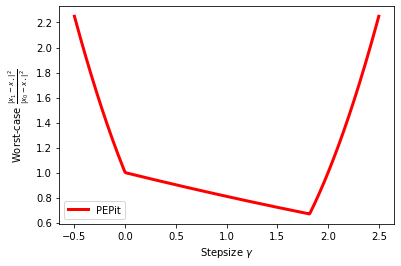

In [3]:
L = 1.
mu = .1
gamma_min, gamma_max = -.5, 2.5
nb_gammas = 400
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()

for i, gamma in enumerate(gamma_list):
    pepit_tau, _, _, _ = wc_gradient_descent(mu=mu,L=L,gammas=[gamma])
    pepit_worst_case_value.append(pepit_tau)
    print(f'{i + 1} / {nb_gammas} grid points computed', end='\r', flush=True)
    
plt.plot(gamma_list, pepit_worst_case_value, color='red', linestyle='-', linewidth=3, label='PEPit')

plt.legend()
plt.xlabel(r'Stepsize $\gamma$')
plt.ylabel(r'Worst-case $\frac{\|x_1-x_\star\|^2}{\|x_0-x_\star\|^2}$')

plt.show()

Verify the output for a few step sizes:

In [4]:
pepit_tau, _, _, _ = wc_gradient_descent(L=L,mu=mu,gammas=[1/L])
[pepit_tau]

[0.8100001805827125]

Identify the pattern in the inequalities: does it make sense, and can you explain it in light of the PEP theory you know?

In [5]:
pepit_tau, list_of_constraints, tab, res  = wc_gradient_descent(1, .1, [1/L])

print(tab["smoothness_strong_convexity"])

IC_Function_0   xs   x0
xs             0.0  1.8
x0             1.8  0.0


Are there other active constraints? (note: you can ignore the "performance metric" constraint for now)

In [6]:
for i, constraint in enumerate(list_of_constraints):
    print('Constraint \"{}\" value: {}'.format(constraint.get_name(),
                                               constraint._dual_variable_value))

Constraint "Performance metric 1" value: 0.9999999999866084
Constraint "Initial condition" value: 0.8100001805827125
Constraint "IC_Function_0_smoothness_strong_convexity(xs, x0)" value: 1.7999998617137993
Constraint "IC_Function_0_smoothness_strong_convexity(x0, xs)" value: 1.7999998617138078


Now, our goal is to compute the optimal point by observing a few properties of the corresponding PEP objects, assuming we do not already know that its parametric value is $2/(L+\mu)$. In particular, observe the value of the residual matrix (at the best point of the grid) and compare it with its value for other step sizes. Can you explain this intuitively? Does it give you a hint on how to algebraically characterize this optimal step size?

In [7]:
idx_best = np.argmin(pepit_worst_case_value)
gamma_best = gamma_list[idx_best]
tau_best = pepit_worst_case_value[idx_best]

pepit_tau, list_of_constraints, tab, res  = wc_gradient_descent(L=L, mu=mu, gammas=[gamma_best])

print(res)

[[ 5.30968577e-05 -5.30968577e-05  5.30953574e-04]
 [-5.30968577e-05  5.30968577e-05 -5.30953574e-04]
 [ 5.30953574e-04 -5.30953574e-04  5.30938571e-03]]


Now that you understand some algebraic properties of the optimal step size, let us try to compute it directly via symbolic computations (using SymPy).

In [8]:
# Proof with SymPy :)
import sympy as sm

# We start by writing the SDP in dual form:

# problem parameters
L, mu, gamma = sm.symbols('L mu gamma')
# primal variables
x0, g0, f0 = sm.symbols('x0 g0 f0')
xs, gs, fs = 0, 0, 0  # wlog optimum at zero
# dual variables
rho, l1, l2 = sm.symbols('rho lambda_1 lambda_2')
# interpolation inequality factory
interp_ij = lambda xi, gi, fi, xj, gj, fj: (
    fi - fj + gi*(xj-xi) + (gi-gj)**2/(2*L)
    + mu/(2*(1-mu/L)) * (xi-xj-(gi-gj)/L)**2
)
# algorithm (GD)
x1 = x0 - gamma * g0

# constraints (≤ 0)
constraint1 = interp_ij(x0, g0, f0, xs, gs, fs)
constraint2 = interp_ij(xs, gs, fs, x0, g0, f0)

# objective and initial condition
primal_objective = (x1 - xs)**2
initial_condition = (x0 - xs)**2 - 1

# Lagrangian
Lagrangian = (
    - l1 * constraint1
    - l2 * constraint2
    - rho * initial_condition
    + primal_objective
)

# Linear matrix inequality (aka. residual on the dual side):
LMI = sm.simplify(sm.hessian(-Lagrangian, (x0, g0)) / 2)
# Linear constraint
Linear = sm.diff(-Lagrangian, f0)

We can now proceed step by step to cancel both terms, namely the LMI/residual and the linear constraint. We show below how to do everything at once, but the step-by-step approach is pedagogically useful and helps one get used to SymPy:

In [9]:
LMI

Matrix([
[(L*lambda_1*mu/2 + L*lambda_2*mu/2 + (L - mu)*(rho - 1))/(L - mu), (-L*lambda_1/2 + gamma*(L - mu) - lambda_2*mu/2)/(L - mu)],
[        (-L*lambda_1/2 + gamma*(L - mu) - lambda_2*mu/2)/(L - mu), (2*gamma**2*(-L + mu) + lambda_1 + lambda_2)/(2*(L - mu))]])

In [10]:
Linear

lambda_1 - lambda_2

In [11]:
# first: substitute one dual variable by the other (as the linear constraint forces them to be equal)
LMI = LMI.subs(l2,l1)
LMI

Matrix([
[            (L*lambda_1*mu + (L - mu)*(rho - 1))/(L - mu), (-L*lambda_1/2 + gamma*(L - mu) - lambda_1*mu/2)/(L - mu)],
[(-L*lambda_1/2 + gamma*(L - mu) - lambda_1*mu/2)/(L - mu),          (2*gamma**2*(-L + mu) + 2*lambda_1)/(2*(L - mu))]])

In [12]:
# Then: pick rho so as to cancel out first entry of the LMI:
rho_val = sm.solve(LMI[0,0],rho)
LMI = sm.simplify(LMI.subs(rho,rho_val[0]))
LMI

Matrix([
[                                                        0, (-L*lambda_1/2 + gamma*(L - mu) - lambda_1*mu/2)/(L - mu)],
[(-L*lambda_1/2 + gamma*(L - mu) - lambda_1*mu/2)/(L - mu),                  (gamma**2*(-L + mu) + lambda_1)/(L - mu)]])

In [13]:
# Then: pick \lambda_1 to cancel out the off-diagonal term:
l1_val = sm.solve(LMI[1,0],l1)
LMI = sm.simplify(LMI.subs(l1,l1_val[0]))
LMI

Matrix([
[0,                                    0],
[0, gamma*(-gamma*(L + mu) + 2)/(L + mu)]])

In [14]:
# Then: pick gamma to cancel out the last term:
gamma_val = sm.solve(LMI[1,1],gamma)
LMI = sm.simplify(LMI.subs(gamma,gamma_val[0]))

# The optimal step size is thus one among the two solutions:
print('There are {} possible solutions'.format(len(gamma_val)))
print('Either gamma={},'.format(gamma_val[0]))
print('or gamma={}.'.format(gamma_val[1]))

There are 2 possible solutions
Either gamma=0,
or gamma=2/(L + mu).


Nice: this is very much in line with what one would expect.
The next lines perform exactly the same operations, but all at once.

In [15]:
# problem parameters
L, mu, gamma = sm.symbols('L mu gamma')
# primal variables
x0, g0, f0 = sm.symbols('x0 g0 f0')
xs, gs, fs = 0, 0, 0  # wlog optimum at zero
# dual variables
rho, l1, l2 = sm.symbols('rho lambda_1 lambda_2')
# interpolation inequality factory
interp_ij = lambda xi, gi, fi, xj, gj, fj: (
    fi - fj + gi*(xj-xi) + (gi-gj)**2/(2*L)
    + mu/(2*(1-mu/L)) * (xi-xj-(gi-gj)/L)**2
)
# algorithm (GD)
x1 = x0 - gamma * g0

# constraints (≤ 0)
constraint1 = interp_ij(x0, g0, f0, xs, gs, fs)
constraint2 = interp_ij(xs, gs, fs, x0, g0, f0)

# objective and initial condition
primal_objective = (x1 - xs)**2
initial_condition = (x0 - xs)**2 - 1

# Lagrangian
Lagrangian = (
    - l1 * constraint1
    - l2 * constraint2
    - rho * initial_condition
    + primal_objective
)

# LMI
LMI = sm.simplify(sm.hessian(-Lagrangian, (x0, g0)) / 2)
Linear = sm.simplify(sm.diff(-Lagrangian,f0))
#LMI = LMI.subs(l2,l1)

sols = sm.solve([LMI,Linear],rho,l1,l2,gamma)

In [16]:
sols[1]

((L - mu)**2/(L + mu)**2,
 4*(L - mu)/(L + mu)**2,
 4*(L - mu)/(L + mu)**2,
 2/(L + mu))

A natural next question is how to turn these findings into a proof of the result:

Method: $x_1=x_0-\gamma \nabla f(x_0)$. The optimal step size is $\tfrac{2}{L+\mu}$, and the proof is as follows. Consider the weighted sum of

- interpolation between $x_0$ and $x_\star$ with weight $\lambda_1=2\gamma (1-\gamma\mu)$
- interpolation between $x_\star$ and $x_0$ with weight $\lambda_2=\lambda_1$

The weighted sum gives (by completing the squares; a.k.a., "analytical Cholesky"):
$$\|x_1-x_\star\|^2\leq (1-\gamma \mu)^2 \|x_0-x_\star\|^2 - \tfrac{\gamma(2-\gamma(L+\mu))}{L-\mu}\|\mu (x_0-x_\star)-\nabla f(x_0)\|^2.$$

Cancelling the last term, we obtain the value for $\gamma$, and the rate $\left(\frac{L-\mu}{L+\mu}\right)^2$.

### 1.2. Multistep gradient descent (aka the Silver step-size schedule [4])

Let us now consider the same optimization setup: we want to minimize a smooth strongly convex function
$$ \min_{x\in\mathbb{R}^d} f(x),$$
but using a multistep gradient algorithm. That is, we will iterate:
\begin{align*}
x_{1} &= x_0 - \gamma_1 \nabla f(x_0),\\
x_{2} &= x_1 - \gamma_2 \nabla f(x_1),
\end{align*}
and our goal will be to design the pair $(\gamma_1, \gamma_2)$. We proceed with the following choice:

$$\min_{\gamma_1,\gamma_2}\,\, \max_{f\in\mathcal{F}_{\mu,L}} \left\{ \frac{\|x_2-x_\star\|^2_2}{\|x_0-x_\star\|^2_2} \, : \, x_2 \text{ obtained from } x_{1} = x_0 - \gamma_1 \nabla f(x_0),\,x_{2} = x_1 - \gamma_2 \nabla f(x_1)  \right\}.$$


To do this, we will follow steps similar to those used for vanilla GD.

For simplicity, let us again carry out the analysis for specific parameter values.

In [17]:
L, mu = 1, .1

The following lines provide helper functions for performing the grid search and plotting the results.

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def pepit_grid_search(gamma1_grid, gamma2_grid, mu, L):
    """
    Evaluate wc_gradient_descent on a grid of (gamma1, gamma2).

    Parameters
    ----------
    gamma1_grid : array-like
        Grid values for gamma1.
    gamma2_grid : array-like
        Grid values for gamma2.
    mu, L : float
        Problem parameters.

    Returns
    -------
    G1, G2 : ndarray
        Meshgrid of gamma1 and gamma2.
    tau_grid : ndarray
        Grid of pepit_tau values.
    """

    G1, G2 = np.meshgrid(gamma1_grid, gamma2_grid)
    tau_grid = np.zeros_like(G1)

    total = tau_grid.size

    for k, (i, j) in enumerate(np.ndindex(G1.shape), start=1):
        gamma1 = G1[i, j]
        gamma2 = G2[i, j]

        pepit_tau, _, _, _ = wc_gradient_descent(mu=mu, L=L, gammas=[gamma1, gamma2])
        tau_grid[i, j] = pepit_tau

        print(f'{k} / {total} grid points computed', end='\r', flush=True)

    return G1, G2, tau_grid

def plot_pepit_landscape(G1, G2, tau_grid):
    """
    Plot the contour landscape of pepit_tau and highlight the minimum.

    Parameters
    ----------
    G1, G2 : ndarray
        Meshgrid of gamma1 and gamma2.
    tau_grid : ndarray
        Grid of pepit_tau values.

    Returns
    -------
    i_best, j_best : int
        Indices of the best grid point.
    gamma1_best, gamma2_best : float
        Best step sizes.
    tau_best : float
        Best value of pepit_tau.
    """

    plt.figure()

    levels = np.logspace(
        np.log10(np.nanmin(tau_grid)),
        np.log10(np.nanmax(tau_grid)),
        50
    )

    cf = plt.contourf(
        G1, G2, tau_grid,
        levels=levels,
        cmap='viridis_r',
        norm=LogNorm()
    )

    plt.colorbar(cf)

    # locate minimum
    idx = np.nanargmin(tau_grid)
    i_best, j_best = np.unravel_index(idx, tau_grid.shape)

    gamma1_best = G1[i_best, j_best]
    gamma2_best = G2[i_best, j_best]
    tau_best = tau_grid[i_best, j_best]

    # mark minimum
    plt.scatter(gamma1_best, gamma2_best, s=120, color='red',
                edgecolor='black', zorder=3)

    plt.xlabel(r'$\gamma_1$')
    plt.ylabel(r'$\gamma_2$')
    plt.title(r'Worst-case $\frac{\|x_2-x_\star\|^2}{\|x_0-x_\star\|^2}$')

    plt.show()

    print(f"Best grid index: (i,j) = ({i_best}, {j_best})")
    print(f"gamma1 = {gamma1_best:.4f}, gamma2 = {gamma2_best:.4f}")
    print(f"tau = {tau_best:.4e}")

    return i_best, j_best, gamma1_best, gamma2_best, tau_best

Using the previous pieces of code, perform a grid search over the step sizes and plot the corresponding convergence rate values.

In [19]:
# 4) plot (2-step)
gamma_min, gamma_max = 0.1, 3.2
nb_gammas = 30

gamma1_vals = np.linspace(gamma_min, gamma_max, nb_gammas)
gamma2_vals = gamma1_vals

G1, G2, tau_grid = pepit_grid_search(gamma1_vals, gamma2_vals, mu=mu, L=L)

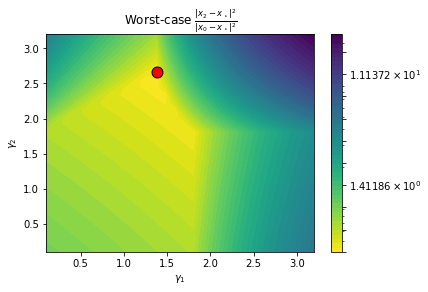

Best grid index: (i,j) = (24, 12)
gamma1 = 1.3828, gamma2 = 2.6655
tau = 4.0889e-01


In [20]:
_, _, gamma1_best, gamma2_best, tau_best = plot_pepit_landscape(G1, G2, tau_grid)

As we want to find properties of the optimal point, let us refine the grid around the target point!

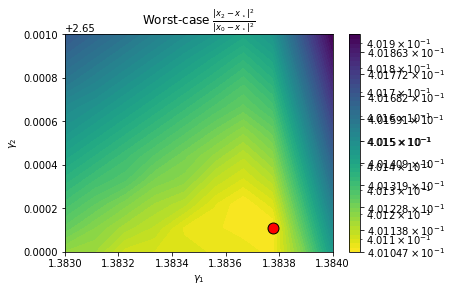

Best grid index: (i,j) = (1, 7)
gamma1 = 1.3838, gamma2 = 2.6501
tau = 4.0105e-01


In [21]:
gamma1_min, gamma1_max = 1.383, 1.384
gamma2_min, gamma2_max = 2.650, 2.651
nb_gammas = 10

gamma1_vals = np.linspace(gamma1_min, gamma1_max, nb_gammas)
gamma2_vals = np.linspace(gamma2_min, gamma2_max, nb_gammas)

G1, G2, tau_grid = pepit_grid_search(gamma1_vals, gamma2_vals, mu=mu, L=L)
_, _, gamma1_best, gamma2_best, tau_best = plot_pepit_landscape(G1, G2, tau_grid)

What algebraic property do you empirically observe at (or around) this optimal point?

In [22]:
pepit_tau, list_of_constraints, tab, res  = wc_gradient_descent(L=L, mu=mu, gammas=[gamma1_best, gamma2_best])

print(res)

[[ 5.83099974e-06 -5.83099974e-06  2.20037443e-05  4.21374901e-05]
 [-5.83099974e-06  5.83099974e-06 -2.20037443e-05 -4.21374901e-05]
 [ 2.20037443e-05 -2.20037443e-05  8.30328905e-05  1.59009192e-04]
 [ 4.21374901e-05 -4.21374901e-05  1.59009192e-04  3.04504914e-04]]


In order to help SymPy, we also have to identify the sparsity pattern for the dual variables. What do you observe and how would you choose it?

In [23]:
print(tab["smoothness_strong_convexity"])

IC_Function_0        xs        x0        x1
xs             0.000000  1.159393  4.231237
x0             0.000206  0.000000  2.089818
x1             5.390423  0.930632  0.000000


Use SymPy to try to compute the optimal step sizes.

In [24]:
# problem parameters
L, mu, gamma1, gamma2 = sm.symbols('L mu gamma1 gamma2', positive=True)

# primal variables
x0, g0, g1, f0, f1 = sm.symbols('x0 g0 g1 f0 f1')
xs, gs, fs = 0, 0, 0  # wlog optimum at zero𝑖

x1 = x0 - gamma1 * g0
x2 = x1 - gamma2 * g1

# dual variables
rho, ls0, ls1, l01, l1s, l10 = sm.symbols('\rho \lambda_{*0} \lambda_{*1} \lambda_{01} \lambda_{1*} \lambda_{10}')


# interpolation inequality factory
interp_ij = lambda xi, gi, fi, xj, gj, fj: (
    fj - fi + gj*(xi-xj) + (gi-gj)**2/(2*L)
    + mu/(2*(1-mu/L)) * (xi-xj-(gi-gj)/L)**2
)

# constraints (≤ 0)
constraints0 = interp_ij(xs, gs, fs, x0, g0, f0)
constraints1 = interp_ij(xs, gs, fs, x1, g1, f1)
constraint01 = interp_ij(x0, g0, f0, x1, g1, f1)
constraint1s = interp_ij(x1, g1, f1, xs, gs, fs)
constraint10 = interp_ij(x1, g1, f1, x0, g0, f0)

# objective and initial condition
primal_objective = (x2 - xs)**2
initial_condition = (x0 - xs)**2 - 1

# Lagrangian
Lagrangian = (
    - ls0 * constraints0
    - ls1 * constraints1
    - l01 * constraint01
    - l1s * constraint1s
    - l10 * constraint10
    - rho * initial_condition
    + primal_objective
)

# LMI
LMI = sm.simplify(sm.hessian(-Lagrangian, (x0, g0, g1)) / 2)
vars_vec = sm.Matrix([f0, f1])
Linear = sm.Matrix([-Lagrangian]).jacobian(vars_vec)

Using the (guessed) algebraic characterization, let us try to obtain closed-form expressions for all the parameters and dual variables. (This will take a few minutes to run.)

In [25]:
sols = sm.solve([LMI,Linear],rho,ls0, ls1, l01, l1s, l10,gamma1,gamma2)

How many solutions did SymPy find? Can you use the numerical experiments to identify which one is relevant here?

In [26]:
print('There are {} solutions'.format(len(sols)))

ind_sol = 3
sols_num = [expr.subs(mu, 0.1).subs(L,1).evalf() for expr in sols[ind_sol]]
print('Solution {} has convergence rate {} for the specific (L,mu) values above'.format(ind_sol, sols_num[0]))

There are 5 solutions
Solution 3 has convergence rate 0.401032645553526 for the specific (L,mu) values above


In [27]:
sols_num

[0.401032645553526,
 1.15927501788681,
 4.23143117213146,
 2.09014864431462,
 5.39070619001826,
 0.930873626427809,
 1.38373600523041,
 2.65027877285182]

What are the corresponding expressions for the step sizes?

In [28]:
simplify_attempt = [sm.simplify(expr) for expr in sols[ind_sol]]

print('First step size is {}'.format(simplify_attempt[-2]))
print('Second step size is {}'.format(simplify_attempt[-1]))

First step size is (-mu + sqrt(2*L**2 - 2*L*mu + mu**2))/(L*(L - mu))
Second step size is (2*L + mu + sqrt(2*L**2 - 2*L*mu + mu**2))/(L*(L + 3*mu))


In [29]:
simplify_attempt[-2]

(-mu + sqrt(2*L**2 - 2*L*mu + mu**2))/(L*(L - mu))

How would you summarize your findings? Do you observe an improvement compared with the classical optimal convergence rate of gradient descent?

#### Summary on Silver steps ($n=2$)

Method: $x_1=x_0-\gamma_1 \nabla f(x_0)$, $x_2=x_1-\gamma_2 \nabla f(x_1)$.
Let us denote by $\lambda_{i,j}$ the weight for using inequality
$$
0\geq f(x_j) -f(x_i) +\langle \nabla f(x_j);x_i-x_j\rangle + \tfrac{1}{2L}\|\nabla f(x_i)-\nabla f(x_j)\|^2+\tfrac{\mu}{2(1-\mu/L)} \|x_i-x_j-\tfrac1L (\nabla f(x_i)-\nabla f(x_j))\|^2.
$$

It seems that we must use the following nonzero values for these weights:

$$
\begin{array}{c|ccc}
(i,j) & \star & 0 & 1 \\
\hline
\star & 0 & ✔ & ✔ \\
0 & 0 & 0 & ✔ \\
1 & ✔ & ✔ & 0
\end{array}
$$

The optimal step sizes are as follows:
\begin{align*}
    \gamma_1 & = \frac{1}{L}\left(\frac{\sqrt{1 + (1-\kappa)^2} - \kappa}{1-\kappa}\right)\\
    \gamma_2 & = \frac{1}{L}\left(\frac{\sqrt{1 + (1-\kappa)^2}+2+\kappa}{1+3\kappa}\right),
\end{align*}
with $\kappa=\tfrac{\mu}{L}$.

The proof consists of performing a weighted sum of inequalities:

- interpolation inequality with $i\leftarrow\star $ and $j\leftarrow0$ and multiplier $\lambda_1=\tfrac{2 \gamma_1 (\kappa -1) ((2 \gamma_2-1) \kappa -1)}{\kappa  (\gamma_1 (-\kappa )+\gamma_1+1)+1}$

- interpolation inequality with $i\leftarrow \star $ and $j\leftarrow 1$ and multiplier $\lambda_2=\tfrac{2 (\kappa -1) (\gamma_1 (\gamma_2-1) \kappa +\gamma_2)}{\kappa  (\gamma_1 (\kappa -1)-1)-1}$

- interpolation inequality with $i\leftarrow 0$ and $j\leftarrow1$ and multiplier $\lambda_3=\tfrac{2 \gamma_1 (\kappa -1) (\gamma_1 \kappa -1) ((2 \gamma_2-1) \kappa -1)}{(\gamma_1 \kappa +\gamma_1-2) (\kappa  (\gamma_1 (-\kappa )+\gamma_1+1)+1)}$

- interpolation inequality with $i\leftarrow 1$ and $j\leftarrow\star$ and multiplier $\lambda_4=\tfrac{2 (\kappa -1) (\gamma_1 (\gamma_2 \kappa -1)-\gamma_2)}{\kappa  (\gamma_1 (-\kappa )+\gamma_1+1)+1}$

- interpolation inequality with $i\leftarrow 1$ and $j\leftarrow0$ and multiplier $\lambda_5=\tfrac{2 (\gamma_1-1) \gamma_1 (\kappa -1) ((2 \gamma_2-1) \kappa -1)}{(\gamma_1 \kappa +\gamma_1-2) (\kappa  (\gamma_1 (\kappa -1)-1)-1)}$

Summing all these inequalities can be reformulated as

\begin{equation*}
\begin{aligned}
\|x_2-x_\star\|^2\leq& \left(\tfrac{2 \kappa  (\gamma_1 (-\gamma_2) \kappa +\gamma_1+\gamma_2)}{\kappa  (\gamma_1 (\kappa -1)-1)-1}+1\right)\|x_0-x_\star\|^2\\&-\tfrac{2 \gamma_1 \left(\gamma_1^2 (\kappa -1)-2 \gamma_1 \kappa +2\right) (\gamma_1 \kappa -1) ((2 \gamma_2-1) \kappa -1)}{(\gamma_1 \kappa +\gamma_1-2) (\kappa  (\gamma_1 (\kappa -1)-1)-1)}\|\nabla f(x_0)\|^2\\&-\tfrac{-2 \gamma_1^2 \gamma_2 (\kappa -1) \kappa  (\gamma_2 \kappa +\gamma_2-2)+2 \gamma_1 \left(\gamma_2 \left(3 \gamma_2 \kappa ^2+\gamma_2-2 (\kappa +1)\right)-2 \kappa +2\right)-4 \gamma_2 (\gamma_2 \kappa +\gamma_2-2)}{(\gamma_1 \kappa +\gamma_1-2) (\kappa  (\gamma_1 (\kappa -1)-1)-1)}\|\nabla f(x_1)\|^2.
\end{aligned}
\end{equation*}

Evaluating this expression at the previously chosen values of $\gamma_1$ and $\gamma_2$, we find that the two residual terms are equal to $0$.



### **Bonus:** more iterations? (hint: using Schur complements might help the numerical exploration, and using other computer-algebra software allows going a bit further than with SymPy)


### Try this pattern on a simple quadratic problem and compare it to vanilla gradient descent


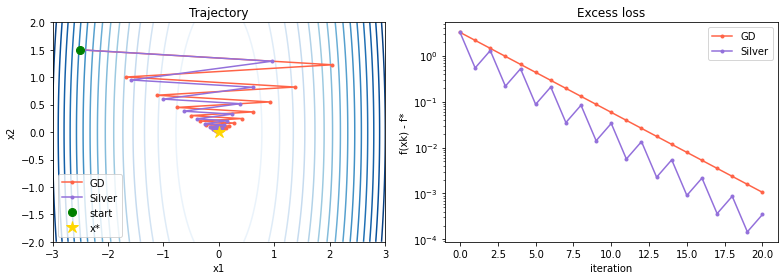

In [30]:
import numpy as np
import matplotlib.pyplot as plt

L, mu = 1., 0.1
kappa = mu / L
H = np.array([L, mu])
grad = lambda x: H * x
f = lambda x: 0.5 * (H * x**2).sum()

def run_gd(x0, T):
    x, traj = x0.copy(), [x0.copy()]
    gamma = 2 / (L + mu)
    for _ in range(T):
        x -= gamma * grad(x)
        traj.append(x.copy())
    return np.array(traj)

def run_silver(x0, T):
    x, traj = x0.copy(), [x0.copy()]
    gamma1 = (np.sqrt(1 + (1-kappa)**2) - kappa) / (L * (1 - kappa))
    gamma2 = (np.sqrt(1 + (1-kappa)**2) + 2 + kappa) / (L * (1 + 3*kappa))
    for _ in range(T):
        x -= gamma1 * grad(x); traj.append(x.copy())
        x -= gamma2 * grad(x); traj.append(x.copy())
    return np.array(traj)

x0 = np.array([-2.5, 1.5])
traj_gd     = run_gd(x0, T=20)
traj_silver = run_silver(x0, T=10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

X, Y = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-2, 2, 200))
ax1.contour(X, Y, 0.5*(H[0]*X**2 + H[1]*Y**2), levels=15, cmap="Blues")
for traj, color, label in [(traj_gd, "tomato", "GD"), (traj_silver, "mediumpurple", "Silver")]:
    ax1.plot(traj[:, 0], traj[:, 1], "o-", color=color, ms=3, label=label)
ax1.plot(*x0, "go", ms=8, label="start")
ax1.plot(0, 0, "*", color="gold", ms=12, label="x*")
ax1.set(title="Trajectory", xlabel="x1", ylabel="x2"); ax1.legend()

ax2.semilogy([f(x) for x in traj_gd],     "o-", color="tomato",       ms=3, label="GD")
ax2.semilogy([f(x) for x in traj_silver],  "o-", color="mediumpurple", ms=3, label="Silver")
ax2.set(title="Excess loss", xlabel="iteration", ylabel="f(xk) - f*"); ax2.legend()

plt.tight_layout(); plt.show()

## 2. Numerical design via ideal algorithms <a class="anchor" id="sec2"></a>

In this section, we perform algorithm design via [5]. That is, we study *ideal* algorithms that are allowed to perform exact line searches
(and even span searches), and deduce, from their analyses and worst-case bounds, algorithms that do not require any such operations.

### 2.1. Back to gradient descent, exact line-search

Start as follows:
$$ x_{k+1}\in\ \underset{x\in \mathbb{R}^d}{\mathrm{argmin}} \left\{f(x):\; x\in x_k+\mathrm{span}\{\nabla f(x_k)\}\right\}.$$
We will design an optimal step size for gradient descent that does not require line search.

We proceed as follows. First, define the target convergence guarantee for gradient descent with exact line search:
$$\rho \triangleq \max_{x_0,x_1, f\in\mathcal{F}_{\mu,L}}\frac{f(x_{1})-f_\star}{f(x_0)-f_\star} \text{  s.t.  } \langle \nabla f(x_1), \nabla f(x_0)\rangle = 0,\ \langle \nabla f(x_1), x_1-x_0\rangle = 0.$$

Then, a natural upper bound from a Lagrangian relaxation with $\lambda_1,\lambda_2\in\mathbb{R}$ is

$$\rho \leq \bar{\rho}(\lambda_1,\lambda_2) \triangleq \max_{x_0, x_1, f\in\mathcal{F}_{\mu,L}} \left\{\frac{f(x_{1})-f_\star}{f(x_0)-f_\star} +\lambda_1 \langle \nabla f(x_1), \nabla f(x_0)\rangle+\lambda_2 \langle \nabla f(x_1), x_1-x_0\rangle\right\}.$$

A similar upper bound can be obtained by combining the inequalities instead (which is a weaker relaxation than putting them directly in the objective):

$$\rho \leq \max_{x_0,x_1, f\in\mathcal{F}_{\mu,L}}\left\{\frac{f(x_{1})-f_\star}{f(x_0)-f_\star} \text{  s.t.  } \lambda_1\langle \nabla f(x_1), \nabla f(x_0)\rangle +\lambda_2 \langle \nabla f(x_1), x_1-x_0\rangle = 0\right\} \leq \bar{\rho}(\lambda_1,\lambda_2).$$

So, for any pair $\lambda_1,\lambda_2\in\mathbb{R}$ we get:
- an upper bound $\bar{\rho}(\lambda_1,\lambda_2)$ (possibly $+\infty$) on $\rho$,
- all methods satisfying $\langle \nabla f(x_1), \lambda_1 \nabla f(x_0)+ \lambda_2  (x_1-x_0)\rangle = 0$ have convergence rate at most $\bar{\rho}(\lambda_1,\lambda_2)$.
- In particular, gradient descent with step size $\frac{\lambda_1}{\lambda_2}$ also benefits from the rate $\bar{\rho}(\lambda_1,\lambda_2)$.

**Bonus:** there exists a choice $\lambda_1^\star,\lambda_2^\star$ such that $\rho=\bar{\rho}(\lambda_1^\star,\lambda_2^\star)$.

#### 2.1.1. Designing an optimal gradient method

Assuming again that we do not know the (worst-case) optimal step-size tuning, the goal here is to recover it from the perspective above.
Again, the motivation is that this perspective allows us to design methods beyond gradient descent, even though the technique can already be fully understood in the gradient-descent setting.

In [31]:
# func values + LS
from PEPit import PEP
from PEPit.functions import SmoothStronglyConvexFunction
from PEPit.primitive_steps import exact_linesearch_step

def wc_gradient_ELS(L, mu, verbose=0):

    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    func = problem.declare_function(SmoothStronglyConvexFunction, L=L, mu=mu, name="f")

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = func.stationary_point(name="xs")
    fs = func(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point(name="x0")
    g0, f0 = func.oracle(x0)

    # Set the initial constraint on function accuracy
    problem.set_initial_condition(f0 - fs <= 1)

    # Run n steps of the Conjugate Gradient method
    x_new = x0
    g0.set_name("grad(x0)")
    x1, g1, f1 = exact_linesearch_step(x0, func, [g0], name='x1')
    g1.set_name('grad(x1)')

    # Set the performance metric to the function value accuracy
    problem.set_performance_metric(f1 - fs)

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)
    list_of_constraints = problem._list_of_prepared_constraints
    
    return pepit_tau, list_of_constraints, func.get_class_constraints_duals(), problem.residual

In [32]:
# verify that LS provides the appropriate step-size strategy!
L, mu = 1, .1
pepit_tau, list_of_constraints, dual_tab, dual_residual = wc_gradient_ELS(L=L,mu=mu)

for i, constraint in enumerate(list_of_constraints):
    print('Constraint \"{}\" value: {}'.format(constraint.get_name(),
                                               constraint._dual_variable_value))
    
pepit_tau

Constraint "Performance metric 1" value: 1.0000000000005818
Constraint "Initial condition" value: 0.6694218823210809
Constraint "IC_f_smoothness_strong_convexity(xs, x0)" value: 0.14876101613030243
Constraint "IC_f_smoothness_strong_convexity(xs, x1)" value: 0.18181918706640812
Constraint "IC_f_smoothness_strong_convexity(x0, xs)" value: 1.094540561619177e-06
Constraint "IC_f_smoothness_strong_convexity(x0, x1)" value: 0.8181812237581545
Constraint "IC_f_smoothness_strong_convexity(x1, xs)" value: 0.0
Constraint "IC_f_smoothness_strong_convexity(x1, x0)" value: 0.0
Constraint "exact_linesearch(f)_to_x1_from_x0" value: 0.9999991045753641
Constraint "exact_linesearch(f)_to_x1_from_x0_in_direction_grad(x0)" value: 1.8181806454530542


0.6694218823210809

In [33]:
list_of_constraints[-1]._dual_variable_value/list_of_constraints[-2]._dual_variable_value
# simplify + resolve!


1.8181822734982545

In [34]:
# proof using SymPy!

### 2.3. Algorithm design for nonsmooth convex minimization

The goal of this section is to apply the same technique to the class of (possibly nonsmooth) convex optimization problems
$$ \min_{x\in\mathbb{R}^d} f(x),$$
where $f$ is convex and $M$-Lipschitz: $|f(x)-f(y)|\leq M\|x-y\|_2$ for all $x,y\in\mathbb{R}^d$ (i.e., for all $x\in\mathbb{R}^d$ and $g_i\in\partial f(x)$ we have $\|g_i\|_2\leq M$).

**Differentiable $f$.** Assume for now that $f$ is differentiable. To design a (hopefully optimal) algorithm for this class, we start by analyzing the following "conjugate gradient-like" method:

$$ x_{k+1} \in \mathrm{argmin}_x\big\{ f(x)\,:\, x\in x_0+\mathrm{span}\{\nabla f(x_0),\nabla f(x_1),\ldots,\nabla f(x_k)\}\big\}.$$

To implement this algorithm within PEPit, we use the [line-search](https://pepit.readthedocs.io/en/latest/api/steps.html#exact-line-search-step) operation, which essentially enforces orthogonality between consecutive search directions and gradients.
That is, it imposes the following constraints (which we directly associate with dual variables):
$$\begin{aligned}
&\langle \nabla f(x_i), \nabla f(x_j)\rangle=0, &&\text{for all } 0\leq j<i=1,\ldots,n &:\beta_{i,j},\\
&\langle \nabla f(x_i), x_j-x_0\rangle=0, &&\text{for all } 1\leq j \leq i=1,\ldots,n &:\gamma_{i,j}.
\end{aligned}$$


Reorganizing those terms, and resorting to relaxation arguments similar to those used for gradient descent with exact line search, one can come up with the following constraint relaxation:

$$\left\langle \nabla f(w_i),\sum_{j=1}^i \beta_{i,j}(w_j-w_0)+\sum_{j=0}^{i-1} \gamma_{i,j}\nabla f(w_j)\right\rangle=0 \quad \text{for all } i=1,\ldots,n,$$

which forms the basis of the *Subspace-search elimination procedure*:

1. Choose $n\geq 0$, $\mathcal{F}$.
2. Find a feasible solution $\{\beta_{i,j}\},\{\gamma_{i,j}\}$ to (dual) PEP for the greedy (conjugate gradient-like) method with guarantee $f(x_n)-f_\star\leq \bar{\tau}$.
3. Any method satisfying
$$\left\langle \nabla f(w_i),\sum_{j=1}^i \beta_{i,j}(w_j-w_0)+\sum_{j=0}^{i-1} \gamma_{i,j}\nabla f(w_j)\right\rangle=0 \quad \text{for all } i=1,\ldots,n$$
benefits from the same worst-case convergence guarantee $f(x_n)-f_\star\leq \bar{\tau}$.

**Possibly nonsmooth $f$.** Finally, when $f$ is possibly nonsmooth, one can apply the same ideas, but use instead

$$ x_{k+1} \in \mathrm{argmin}_x\big\{ f(x)\,:\, x\in x_0+\mathrm{span}\{g_0, g_1,\ldots,g_k\}\big\}$$

where $g_i\in \partial f(x_i)$ such that $\langle g_i,g_j\rangle = 0$ for all $i,j$: $0\leq j<i$.

#### 2.3.1. Analyzing the conjugate gradient-like algorithm

In [35]:
from math import sqrt

from PEPit import PEP
from PEPit.functions import ConvexLipschitzFunction
from PEPit.primitive_steps import exact_linesearch_step

import numpy as np

def wc_conjugate_gradient_nonsmooth(M, R, n, verbose=0):

    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    func = problem.declare_function(ConvexLipschitzFunction, M=M, name="f")

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = func.stationary_point(name="xs")
    fs = func(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point(name="x0")

    # Set the initial constraint that is the distance between x0 and x_*
    problem.set_initial_condition((x0 - xs) ** 2 <= R**2)

    # Run n steps of the Conjugate Gradient method
    x_new = x0
    g0, f0 = func.oracle(x0)
    g0.set_name("grad(x0)")
    span = [g0]  # list of search directions
    for i in range(n):
        x_old = x_new
        x_new, gx, fx = exact_linesearch_step(x0, func, span, name='x{}'.format(i+1))
        gx.set_name('grad(x{})'.format(i+1))
        span.append(gx)
        newdir = x_new - x0
        newdir.set_name('{}-{}'.format(x_new.get_name(), x0.get_name()))
        span.append(newdir)

    # Set the performance metric to the function value accuracy
    problem.set_performance_metric(fx - fs)

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)
    list_of_constraints = problem._list_of_prepared_constraints

    return pepit_tau, list_of_constraints, problem

In [36]:
# This creates helper functions (for later usage)
print("Creating helper functions (for appropriate constraint and dual variables selections)")

import re

def helper_non_smooth_constraint_deactivation(list_of_constraints):
    for constraint in list_of_constraints:
        constraint.deactivate()

    list_of_constraints[0].activate()
    list_of_constraints[1].activate()

    for constraint in list_of_constraints:
        name = constraint.get_name()
        m0 = re.match(r'IC_f_lipschitz_continuity\(xs\)', name)
        m1 = re.match(r'IC_f_lipschitz_continuity\(x(\d+)\)', name)
        m2 = re.match(r'IC_f_convexity\(xs, x(\d+)\)', name)
        m3 = re.match(r'IC_f_convexity\(x(\d+), x(\d+)\)', name)
        m4 = re.match(r'exact_linesearch\(f\)_to_x(\d+)_from_x0$', name)
        m5 = re.match(r'exact_linesearch\(f\)_to_x(\d+)_from_x0_in_direction_grad\(x(\d+)\)', name)
        m6 = re.match(r'exact_linesearch\(f\)_to_x(\d+)_from_x0_in_direction_x(\d+)-x0', name)
        activate = (
            m0 or
            m1 or
            m2 or
            (m3 and int(m3.group(2)) == int(m3.group(1)) + 1) or
            m4 or
            m5 or
            (m6 and int(m6.group(2)) == int(m6.group(1)) - 1)
        )
        if activate:
            constraint.activate()
            
def helper_extract_betas_gammas(list_of_constraints):
    # Parse constraints into a dict
    dual_vals = {c.get_name(): c._dual_variable_value for c in list_of_constraints}

    # Infer n from constraint names
    all_indices = []
    for name in dual_vals:
        for m in re.finditer(r'x(\d+)', name):
            all_indices.append(int(m.group(1)))
    n = max(all_indices) if all_indices else 0

    # Initialize tables
    gamma_table = np.zeros((n+1, n+1))  # gamma[i,j]: dual of <g_i, x_j - x_0> == 0
    beta_table  = np.zeros((n+1, n+1))  # beta[i,j]:  dual of <g_i, g_j> == 0

    for name, val in dual_vals.items():
        # gamma[i,i]: "exact_linesearch(f)_to_xi_from_x0"  <-> <g_i, x_i - x_0> == 0
        m = re.match(r'exact_linesearch\(f\)_to_x(\d+)_from_x0$', name)
        if m:
            i = int(m.group(1))
            gamma_table[i, i] = val
            continue

        # gamma[i,j]: "exact_linesearch(f)_to_xi_from_x0_in_direction_xj-x0"  <-> <g_i, x_j - x_0> == 0
        m = re.match(r'exact_linesearch\(f\)_to_x(\d+)_from_x0_in_direction_x(\d+)-x0', name)
        if m:
            i, j = int(m.group(1)), int(m.group(2))
            gamma_table[i, j] = val
            continue

        # beta[i,j]: "exact_linesearch(f)_to_xi_from_x0_in_direction_grad(xj)"  <-> <g_i, g_j> == 0
        m = re.match(r'exact_linesearch\(f\)_to_x(\d+)_from_x0_in_direction_grad\(x(\d+)\)', name)
        if m:
            i, j = int(m.group(1)), int(m.group(2))
            beta_table[i, j] = val

    print("gamma[i,j] table (dual of <g_i, x_j - x_0> == 0):")
    print(np.array2string(gamma_table, precision=4, suppress_small=True))
    print("\nbeta[i,j] table (dual of <g_i, g_j> == 0):")
    print(np.array2string(beta_table, precision=4, suppress_small=True))

    return gamma_table, beta_table 

Creating helper functions (for appropriate constraint and dual variables selections)


#### 2.3.2. Experimenting with small time horizons ($n=1,2$)

Experiment with $n=1,2$: what do you observe? Can you find algorithms (without line or span searches) that match the performance of the greedy conjugate gradient algorithm?

In [37]:
# Experiment here
M, R = 1, 1
n = 2

pepit_tau, list_of_constraints, pep_prob = wc_conjugate_gradient_nonsmooth(M, R, n, verbose=0)

[pepit_tau, 1/np.sqrt(n+1)]

[0.5773502841545819, 0.5773502691896258]

In [38]:
# Experiment here, implement the corresponding algorithms: are the specific guarantees for those algorithms matching those of the conjugate gradient-like method?

#### 2.3.3. General $n$

The following lines deactivate the appropriate constraints and allow us to recover the corresponding tables of multipliers $\beta_{i,j}$ and $\gamma_{i,j}$.

In [39]:
M, R = 1, 1
n = 4

pepit_tau, list_of_constraints, pep_prob = wc_conjugate_gradient_nonsmooth(M, R, n, verbose=0)

helper_non_smooth_constraint_deactivation(list_of_constraints)

verbose = 0
pep_prob.solve(verbose=verbose)

if verbose:
    for i, constraint in enumerate(list_of_constraints):
        print('Constraint \"{}\" value: {}'.format(constraint.get_name(),
                                                   constraint._dual_variable_value))
        
gamma_table, beta_table = helper_extract_betas_gammas(list_of_constraints)

gamma[i,j] table (dual of <g_i, x_j - x_0> == 0):
[[ 0.   0.   0.   0.   0. ]
 [ 0.   0.4  0.   0.   0. ]
 [ 0.  -0.4  0.6  0.   0. ]
 [ 0.   0.  -0.6  0.8  0. ]
 [ 0.   0.   0.  -0.8  1. ]]

beta[i,j] table (dual of <g_i, g_j> == 0):
[[0.     0.     0.     0.     0.    ]
 [0.0894 0.     0.     0.     0.    ]
 [0.0894 0.0894 0.     0.     0.    ]
 [0.0894 0.0894 0.0894 0.     0.    ]
 [0.0894 0.0894 0.0894 0.0894 0.    ]]


Propose and implement an algorithm that performs as well as CG!

In [40]:
# Your answer here

In [41]:
scaled_gamma_table = (n+1) * gamma_table
scaled_beta_table = (n+1)**(3/2) * beta_table

print("gamma[i,j] table (dual of <g_i, x_j - x_0> == 0):")
print(np.array2string(scaled_gamma_table, precision=2, suppress_small=True))
print("\nbeta[i,j] table (dual of <g_i, g_j> == 0):")
print(np.array2string(scaled_beta_table, precision=2, suppress_small=True))

gamma[i,j] table (dual of <g_i, x_j - x_0> == 0):
[[ 0.  0.  0.  0.  0.]
 [ 0.  2.  0.  0.  0.]
 [ 0. -2.  3.  0.  0.]
 [ 0.  0. -3.  4.  0.]
 [ 0.  0.  0. -4.  5.]]

beta[i,j] table (dual of <g_i, g_j> == 0):
[[0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 0.]]


It therefore looks like we can collect the coefficients and obtain clean constraints:

Denote by $g_i\in\partial f(x_i)$; then all methods satisfying
$$ 0=\left< g_i,x_i-\left[\frac{i}{i+1}x_{i-1}+\frac{1}{i+1}x_0-\frac{1}{i+1} \frac{R}{M\sqrt{n+1}}\sum_{j=0}^{i-1}g_j \right]\right> $$ 
benefit from the worst-case guarantee
$$ f(x_n)-f_\star \leq \frac{M R}{\sqrt{n+1}}.$$ 
Below is a PEPit implementation of the resulting algorithm (sometimes referred to as a "quasi-monotone subgradient method" [7], since the worst-case guarantee is monotone).

In [42]:
def wc_quasi_monotone(M, R, n, verbose=0):

    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    func = problem.declare_function(ConvexLipschitzFunction, M=M, name="f")

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = func.stationary_point(name="xs")
    fs = func(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point(name="x0")

    # Set the initial constraint that is the distance between x0 and x_*
    problem.set_initial_condition((x0 - xs) ** 2 <= R**2)

    # Run n steps of the Conjugate Gradient method
    x = x0
    di = 0*x0
    for i in range(n):
        yi = (i+1)/(i+2)* x + 1/(i+2) * x0
        di = ((i+1) * di + func.gradient(x))/(i+2)
        x = yi - di / np.sqrt(n+1) / M * R

    # Set the performance metric to the function value accuracy
    problem.set_performance_metric(func(x) - fs)

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)
    list_of_constraints = problem._list_of_prepared_constraints

    return pepit_tau, list_of_constraints, problem

In [43]:
# Verify numerical values

M, R, n = 1, 1, 10
pepit_tau1, _, _ = wc_quasi_monotone(M,R,n)
pepit_tau2, _, _ = wc_conjugate_gradient_nonsmooth(M, R, n)

[pepit_tau1, pepit_tau2]

[0.30150888838186735, 0.30151276363482477]

## 3. Back to smooth convex minimization: the optimized gradient method <a class="anchor" id="sec3"></a>

The goal of this section is to apply the same technique to the class of smooth convex optimization problems
$$ \min_{x\in\mathbb{R}^d} f(x),$$

and to verify that the resulting algorithm matches the optimized gradient method (OGM) [1, 3].

### 3.1. Conjugate gradient method

In [44]:
from math import sqrt

from PEPit import PEP
from PEPit.functions import SmoothConvexFunction
from PEPit.primitive_steps import exact_linesearch_step

def wc_conjugate_gradient(L, n, verbose=1):

    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    func = problem.declare_function(SmoothConvexFunction, L=L, name="f")

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = func.stationary_point(name="xs")
    fs = func(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point(name="x0")

    # Set the initial constraint that is the distance between x0 and x_*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1)

    # Run n steps of the Conjugate Gradient method
    x_new = x0
    g0, f0 = func.oracle(x0)
    g0.set_name("grad(x0)")
    span = [g0]  # list of search directions
    for i in range(n):
        x_old = x_new
        x_new, gx, fx = exact_linesearch_step(x_new, func, span)
        x_new.set_name('x{}'.format(i+1))
        gx.set_name('grad(x{})'.format(i+1))
        span.append(gx)
        newdir = x_old - x_new
        newdir.set_name('{}-{}'.format(x_old.get_name(), x_new.get_name()))
        span.append(newdir)

    # Set the performance metric to the function value accuracy
    problem.set_performance_metric(fx - fs)

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)
    list_of_constraints = problem._list_of_prepared_constraints

    return pepit_tau, list_of_constraints

## HELPER

Experiment with small values of the time horizon (e.g., $n=1,2$) and try to come up with the coefficients of the method.

In [45]:
L = 1
n = 2

pepit_tau, list_of_constraints = wc_conjugate_gradient(L, n, verbose=1)

(PEPit) Setting up the problem: performance measure is the minimum of 1 element(s)
(PEPit) Setting up the problem: Adding initial conditions and general constraints ...
(PEPit) Setting up the problem: initial conditions and general constraints (1 constraint(s) added)
(PEPit) Setting up the problem: interpolation conditions for 1 function(s)
			Function 1 : Adding 12 scalar constraint(s) ...
			Function 1 : 12 scalar constraint(s) added
(PEPit) Setting up the problem: additional constraints for 1 function(s)
			Function 1 : Adding 6 scalar constraint(s) ...
			Function 1 : 6 scalar constraint(s) added
(PEPit) Setting up the problem: size of the Gram matrix: 7x7
(PEPit) Compiling SDP
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (wrapper:cvxpy, solver: SCS); optimal value: 0.06189419366127077
(PEPit) Primal feasibility check:
		The solver found a Gram matrix that is positive semi-definite
		All the primal scalar constraints are verified up to an error of 8.378963981675591e-08

In [46]:
for i, constraint in enumerate(list_of_constraints):
    print('Constraint \"{}\" value: {}'.format(constraint.get_name(),
                                               constraint._dual_variable_value))

Constraint "Performance metric 1" value: 1.000000000000051
Constraint "Initial condition" value: 0.061894195562268266
Constraint "IC_f_smoothness_convexity(xs, x0)" value: 0.24757674917197692
Constraint "IC_f_smoothness_convexity(xs, x1)" value: 0.40058761240389895
Constraint "IC_f_smoothness_convexity(xs, x2)" value: 0.35183569826399763
Constraint "IC_f_smoothness_convexity(x0, xs)" value: 0.0
Constraint "IC_f_smoothness_convexity(x0, x1)" value: 0.2475767204719302
Constraint "IC_f_smoothness_convexity(x0, x2)" value: 0.0
Constraint "IC_f_smoothness_convexity(x1, xs)" value: 0.0
Constraint "IC_f_smoothness_convexity(x1, x0)" value: 0.0
Constraint "IC_f_smoothness_convexity(x1, x2)" value: 0.6481642905905665
Constraint "IC_f_smoothness_convexity(x2, xs)" value: 0.0
Constraint "IC_f_smoothness_convexity(x2, x0)" value: 0.0
Constraint "IC_f_smoothness_convexity(x2, x1)" value: 0.0
Constraint "exact_linesearch(f)_to_new_x_from_x0" value: 0.6481643368849084
Constraint "exact_linesearch(f)_

In [47]:
# Experiment and identify a relevent pattern of active inequalities (for small values of $n$ and $L=1$)

### 3.2. The optimized gradient method (OGM)

Verify that the same worst-case guarantees are valid for the following algorithm.

In [48]:
from math import sqrt

from PEPit import PEP
from PEPit.functions import SmoothConvexFunction

def wc_optimized_gradient(L, n, wrapper="cvxpy", solver=None, verbose=1):

    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    func = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = func.stationary_point()
    fs = func(xs)

    # Then Define the starting point of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1)

    # Run n steps of the optimized gradient method (OGM) method
    theta_new = 1
    x_new = x0
    y = x0
    for i in range(n):
        x_old = x_new
        x_new = y - 1 / L * func.gradient(y)
        theta_old = theta_new
        if i < n - 1:
            theta_new = (1 + sqrt(4 * theta_new ** 2 + 1)) / 2
        else:
            theta_new = (1 + sqrt(8 * theta_new ** 2 + 1)) / 2

        y = x_new + (theta_old - 1) / theta_new * (x_new - x_old) + theta_old / theta_new * (x_new - y)

    # Set the performance metric to the function value accuracy
    problem.set_performance_metric(func(y) - fs)

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(wrapper=wrapper, solver=solver, verbose=pepit_verbose)

    # Compute theoretical guarantee (for comparison)
    theoretical_tau = L / (2 * theta_new ** 2)

    # Return the worst-case guarantee of the evaluated method (and the reference theoretical value)
    return pepit_tau, theoretical_tau

What we do next is to *unroll* the algorithms (the conjugate-gradient-based one and the optimized gradient method) to form their respective coefficient matrices $\{h_{i,j}\}$:
$$\begin{aligned}
x_1 &= x_0 - h_{1,0} \nabla f(x_0),\\
x_2 &= x_1 - h_{2,0} \nabla f(x_0) - h_{2,1} \nabla f(x_1),\\
x_3 &= x_2 - h_{3,0} \nabla f(x_0) - h_{3,1} \nabla f(x_1) - h_{3,2} \nabla f(x_2),\\
&\vdots\\
x_N &= x_{N-1} - \sum_{i=0}^{N-1} h_{N,i} \nabla f(x_i),
\end{aligned}$$
and compare them to check that they match.

In [49]:
import numpy as np

def plot_ogm_step_sizes(step_sizes):
    """
    Compare a user-provided lower-triangular coefficient table against the
    unrolled OGM coefficients from Kim--Fessler (equations (6.16) and (7.1)).

    Args:
        step_sizes (array-like): either
            - a list of rows, where row i contains [h_{i+1,0}, ..., h_{i+1,i}], or
            - a square lower-triangular array whose upper triangle is ignored.

    Returns:
        np.ndarray: the OGM coefficient table as an n x n lower-triangular array.
    """
    if isinstance(step_sizes, np.ndarray):
        user_steps = np.asarray(step_sizes, dtype=float)
    else:
        user_steps = np.asarray(step_sizes, dtype=object)

    if user_steps.ndim == 2 and user_steps.shape[0] == user_steps.shape[1]:
        n = user_steps.shape[0]
        user_table = np.full((n, n), np.nan)
        for i in range(n):
            user_table[i, :i + 1] = user_steps[i, :i + 1]
    else:
        n = len(step_sizes)
        user_table = np.full((n, n), np.nan)
        for i, row in enumerate(step_sizes):
            row = np.asarray(row, dtype=float).ravel()
            if row.size != i + 1:
                raise ValueError(
                    f"Row {i} should contain {i + 1} coefficients, got {row.size}."
                )
            user_table[i, :i + 1] = row

    theta = [1.0]
    for i in range(n):
        if i < n - 1:
            theta.append((1 + np.sqrt(1 + 4 * theta[-1] ** 2)) / 2)
        else:
            theta.append((1 + np.sqrt(1 + 8 * theta[-1] ** 2)) / 2)

    ogm_table = np.full((n, n), np.nan)
    previous_row = None
    for i in range(n):
        row = np.zeros(i + 1)
        if i >= 2:
            row[:i - 1] = (theta[i] - 1) / theta[i + 1] * previous_row[:i - 1]
        if i >= 1:
            row[i - 1] = (theta[i] - 1) / theta[i + 1] * (previous_row[i - 1] - 1)
        row[i] = 1 + (2 * theta[i] - 1) / theta[i + 1]
        ogm_table[i, :i + 1] = row
        previous_row = row

    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="white")
    values = np.concatenate((user_table[~np.isnan(user_table)], ogm_table[~np.isnan(ogm_table)]))
    vmin, vmax = values.min(), values.max()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    for ax, table, title in zip(axes, [user_table, ogm_table], ["Your coefficients", "OGM coefficients"]):
        im = ax.imshow(table, origin="upper", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel(r"Gradient index $j$")
        ax.set_ylabel(r"Step $i+1$")
        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        ax.set_yticklabels(range(1, n + 1))

    fig.colorbar(im, ax=axes, shrink=0.85, label=r"Coefficient $h_{i,j}$")
    return ogm_table

In [50]:
# Put your unrolled coefficients here as a lower-triangular list of rows,
# for example [[h_1,0], [h_2,0, h_2,1], [h_3,0, h_3,1, h_3,2]].
# Then run this cell to compare them with the OGM coefficients.

your_step_sizes = [
    [1.0],
    [1.0, 1.0],
]

plot_ogm_step_sizes(your_step_sizes);

AttributeError: 'ListedColormap' object has no attribute 'copy'

### 3.3. Missing details.

In order to *construct* these numerical algorithms, one often simply observes the coefficient matrices $\{h_{i,j}\}$ (think of what would happen if you were actually solving the minimax optimization problem over the coefficients of the algorithm).
In this case, one typically resorts to additional numerical experiments aimed at understanding the structural properties of the algorithm:
- what are the key inequalities to be used in the corresponding worst-case analysis?
- Can the method be *factorized* in a nice way (that does not require storing all past gradients)?
- Can we identify a compact proof (e.g., Lyapunov-based) that would make the analysis simpler?

It turns out that the answers to these questions are, perhaps luckily, relatively nice in the case of the optimized gradient method.
We illustrate a potential/Lyapunov-based analysis of OGM below.

### 3.4. Potential/Lyapunov proof for the optimized gradient method

Use PEPit to verify the following inequality for the iterates of the optimized gradient method (for simplicity, assume $k<N$):

$$
\phi_{k}\leq \phi_{k-1},
$$
with $$\phi_k\triangleq 2\theta_{k,N}^2 \left(f(y_k) - f_\star - \frac{1}{2L}\lVert \nabla f(y_k) \rVert_2^2 \right) + \frac{L}{2}\|z_{k+1} - x_\star\|_2^2.$$

In [51]:
from math import sqrt

from PEPit import PEP
from PEPit.functions import SmoothConvexFunction

def potential_function_optimized_gradient(L, thetak_m1, verbose=1):

    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    func = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = func.stationary_point(name='xs')
    fs = func(xs)

    # Define y_{k-1} and z_k
    yk_m1 = problem.set_initial_point()
    zk = problem.set_initial_point()
    
    # Compute thetak 
    thetak = (1 + np.sqrt( 4 * thetak_m1**2 + 1) ) / 2
    
    c = (1-1/thetak)
    yk = c * ( yk_m1 - 1/L * func.gradient(yk_m1) ) + (1-c) * zk
    zk_p1 = zk - 2/L * thetak * func.gradient(yk)
    
    yk_m1.set_name('y_{k-1}')
    yk.set_name('y_k')

    # Define the potential function values
    phik_m1 = 2*thetak_m1**2 * ( func(yk_m1) - fs - 1/2/L * func.gradient(yk_m1)**2 ) + L/2 * (zk-xs)**2
    phik = 2*thetak**2 * ( func(yk) - fs - 1/2/L * func.gradient(yk)**2 ) + L/2 * (zk_p1-xs)**2
    
    problem.set_initial_condition(phik_m1 <= 1)
    problem.set_performance_metric(phik)

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)
    list_of_constraints = problem._list_of_prepared_constraints

    # Return the worst-case guarantee of the evaluated method (and the reference theoretical value)
    return pepit_tau, list_of_constraints, problem

In [52]:
L, thetak_m1 = 1., 1.
pepit_tau, list_of_constraints, problem = potential_function_optimized_gradient(L, thetak_m1, verbose=1)

for i, constraint in enumerate(list_of_constraints):
    print('Constraint \"{}\" value: {}'.format(constraint.get_name(),
                                               constraint._dual_variable_value))

(PEPit) Setting up the problem: performance measure is the minimum of 1 element(s)
(PEPit) Setting up the problem: Adding initial conditions and general constraints ...
(PEPit) Setting up the problem: initial conditions and general constraints (1 constraint(s) added)
(PEPit) Setting up the problem: interpolation conditions for 1 function(s)
			Function 1 : Adding 6 scalar constraint(s) ...
			Function 1 : 6 scalar constraint(s) added
(PEPit) Setting up the problem: additional constraints for 0 function(s)
(PEPit) Setting up the problem: size of the Gram matrix: 5x5
(PEPit) Compiling SDP
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (wrapper:cvxpy, solver: SCS); optimal value: 0.9999999335394925
(PEPit) Primal feasibility check:
		The solver found a Gram matrix that is positive semi-definite
		All the primal scalar constraints are verified up to an error of 1.6263634718960418e-06
(PEPit) Dual feasibility check:
		The solver found a residual matrix that is positive semi-defin

In [53]:
# After carefully selecting active constraints: can you use SymPy to search & verify your proof?
#
#

**Summary.** The inequality can be obtained from the same potential used for OGM, itself derived from additional inequalities. That is, we first perform a weighted sum of the following inequalities (this is actually for conjugate gradients, but it also works for OGM).

- **Smoothness and convexity of $f$ between $y_{k-1}$ and $y_k$ with weight $\lambda_1 = 2\theta_{k-1,N}^2$:**

$$
0 \geq f(y_k) - f(y_{k-1}) + \langle \nabla f(y_k); y_{k-1} - y_k \rangle
+ \frac{1}{2L}\lVert \nabla f(y_k) - \nabla f(y_{k-1}) \rVert_2^2.
$$

- **Smoothness and convexity of $f$ between $x_\star$ and $y_k$ with weight $\lambda_2 = 2\theta_{k,N}$:**

$$
0 \geq f(y_k) - f(x_\star)
+ \langle \nabla f(y_k); x_\star - y_k \rangle
+ \frac{1}{2L}\lVert \nabla f(y_k) \rVert_2^2.
$$

- **Search procedure to obtain $y_k$, with weight $\lambda_3 = 2\theta_{k,N}^2$:**

$$
0 \geq
\left\langle
\nabla f(y_k),
y_k -
\left[
\left(1 - \frac{1}{\theta_{k,N}}\right)
\left(y_{k-1} - \tfrac{1}{L}\nabla f(y_{k-1})\right)
+ \frac{1}{\theta_{k,N}} z_k
\right]
\right\rangle,
$$

where $
z_k := y_0 - \frac{2}{L}\sum_{j=0}^{k-1}\theta_{j,N}\nabla f(y_j)$.

---

The weighted sum is a valid inequality:

$$
\begin{aligned}
0 \geq
&\lambda_1 \Big[
f(y_k) - f(y_{k-1})
+ \langle \nabla f(y_k); y_{k-1} - y_k \rangle
+ \frac{1}{2L}\lVert \nabla f(y_k) - \nabla f(y_{k-1}) \rVert_2^2
\Big] \\
&+ \lambda_2 \Big[
f(y_k) - f(x_\star)
+ \langle \nabla f(y_k); x_\star - y_k \rangle
+ \frac{1}{2L}\lVert \nabla f(y_k) \rVert_2^2
\Big] \\
&+ \lambda_3 \Big[
\langle
\nabla f(y_k),
y_k -
\Big(
(1-\tfrac{1}{\theta_{k,N}})
(y_{k-1}-\tfrac{1}{L}\nabla f(y_{k-1}))
+ \tfrac{1}{\theta_{k,N}} z_k
\Big)
\rangle
\Big].
\end{aligned}
$$

Substituting $z_{k+1}$, the previous inequality can be reformulated exactly as

$$
\begin{aligned}
0 \geq
&2\theta_{k,N}^2
\left(
f(y_k) - f_\star
- \frac{1}{2L}\lVert \nabla f(y_k) \rVert_2^2
\right)
+ \frac{L}{2}\|z_{k+1} - x_\star\|_2^2 \\
&- 2\theta_{k-1,N}^2
\left(
f(y_{k-1}) - f_\star
- \frac{1}{2L}\lVert \nabla f(y_{k-1}) \rVert_2^2
\right)
- \frac{L}{2}\|z_k - x_\star\|_2^2 \\
&+ 2(\theta_{k-1,N}^2 - \theta_{k,N}^2 + \theta_{k,N})
\left(
f(y_k) - f_\star
+ \frac{1}{2L}\|\nabla f(y_k)\|_2^2
\right) \\
&+ 2(\theta_{k-1,N}^2 - \theta_{k,N}^2 + \theta_{k,N})
\left\langle
\nabla f(y_k),
y_{k-1} - \tfrac{1}{L}\nabla f(y_{k-1}) - y_k
\right\rangle .
\end{aligned}
$$

We reach the desired inequality by selecting $\theta_{k,N}$ such that

- $\theta_{k,N} \geq \theta_{k-1,N}$  
- 
$
\theta_{k-1,N}^2 - \theta_{k,N}^2 + \theta_{k,N} = 0.
$

So we pick $\theta_{k,N}$ as the largest root of the previous quadratic equation, reaching the potential function inequality:
$$
2\theta_{k,N}^2
\left(
f(y_k) - f_\star
- \frac{1}{2L}\lVert \nabla f(y_k) \rVert_2^2
\right)
+ \frac{L}{2}\|z_{k+1} - x_\star\|_2^2  \leq 2\theta_{k-1,N}^2
\left(
f(y_{k-1}) - f_\star
- \frac{1}{2L}\lVert \nabla f(y_{k-1}) \rVert_2^2
\right)
+ \frac{L}{2}\|z_k - x_\star\|_2^2
$$


### 4. Going further <a class="anchor" id="sec4"></a>

- Algorithm design based on nonlinear optimization; see, for instance, [8, 9]. Recent algorithms designed using such techniques include those in [9, 10, 12].
A few easy-to-interface solvers may also become available through CVXPY (e.g., [DNLP](https://github.com/cvxgrp/dnlp-examples/blob/main/nlp_examples/trimmed_log_reg.py)).
- Design based on convex relaxations, see, e.g., constructions in [1, 3, 11].
- Algebraic techniques for solving linear matrix inequalities (more to come!)

---

### References

[1] Y. Drori and M. Teboulle, *Performance of first-order methods for smooth convex minimization: a novel approach*, Mathematical Programming, 2014. [arXiv:1206.3209](https://arxiv.org/abs/1206.3209)

[2] A. B. Taylor, J. M. Hendrickx, and F. Glineur, *Smooth strongly convex interpolation and exact worst-case performance of first-order methods*, Mathematical Programming, 2017. [arXiv:1502.05666](https://arxiv.org/abs/1502.05666)

[3] D. Kim and J. A. Fessler, *Optimized first-order methods for smooth convex minimization*, Mathematical Programming, 2016. [arXiv:1406.5468](https://arxiv.org/abs/1406.5468)

[4] J. M. Altschuler and P. A. Parrilo, *Acceleration by Stepsize Hedging I: Multi-Step Descent and the Silver Stepsize Schedule*, Journal of the ACM, 2025. [arXiv:2309.07879](https://arxiv.org/abs/2309.07879)

[5] Y. Drori and A. B. Taylor, *Efficient first-order methods for convex minimization: a constructive approach*, Mathematical Programming, 2020. [arXiv:1803.05676](https://arxiv.org/abs/1803.05676)

[6] E. De Klerk, F. Glineur, A. B. Taylor, *On the worst-case complexity of the gradient method with exact line search for smooth strongly convex functions*, Optimization Letters, 2017. [arXiv:1606.09365](https://arxiv.org/abs/1606.09365)

[7] Y. Nesterov and V. Shikhman, *Quasi-monotone subgradient methods for nonsmooth convex minimization*, Journal of Optimization Theory and Applications, 2015.

[8] Y. Kamri, J. M. Hendrickx, and F. Glineur, *Numerical Design of Optimized First-Order Algorithms*, 2025. [arXiv:2507.20773](https://arxiv.org/abs/2507.20773)

[9] S. Das Gupta, B. P. G. Van Parys, and E. K. Ryu, *Branch-and-bound performance estimation programming: a unified methodology for constructing optimal optimization methods*, Mathematical Programming, 2024. [arXiv:2203.07305](https://arxiv.org/abs/2203.07305)

[10] D. Kim and J. A. Fessler, *Optimizing the efficiency of first-order methods for decreasing the gradient of smooth convex functions*, Journal of Optimization Theory and Applications, 2021. [arXiv:1803.06600](https://arxiv.org/abs/1803.06600)

[11] Y. Drori and A. B. Taylor, *An optimal gradient method for smooth strongly convex minimization*, Mathematical Programming, 2022. [arXiv:2101.09741](https://arxiv.org/abs/2101.09741)

[12] U. Jang, S. Das Gupta, and E. K. Ryu, *Computer-Assisted Design of Accelerated Composite Optimization Methods: OptISTA*, Mathematical Programming, 2025. [arXiv:2305.15704](https://arxiv.org/abs/2305.15704)